
# Animated Gradient Sankey Diagrams
### A technical journey: from a consulting pain‑point to an open‑source visualization library

*Felipe Gabriel — financial data & quantitative visualization*
**Repo:** https://github.com/FG-SC/gradient-sankey  ·  `pip install gradient-sankey`

---

## TL;DR

As a consultant I kept needing to show **how a company's income statement (P&L / "DRE") evolves over time** to executives and clients. A Sankey diagram is the natural tool — money *flows* from revenue down to net income — but every off‑the‑shelf library renders links as **flat, single‑colored ribbons**, which makes a multi‑stage waterfall hard to read and frankly dull in a board deck.

So I built a library that renders **true RGB‑gradient links** (the ribbon morphs from the source node's color to the target's), then extended it into a **parallel animation engine**. The capstone is an animated reel of **NVIDIA's quarterly income statement, FY2009 → FY2027**, driven by **real SEC EDGAR filings**, with a synchronized **split‑adjusted stock‑price overlay**.

This notebook tells the whole story — the math, the engineering, the data pipeline, and the bugs I had to kill along the way.



## 1. The problem, precisely

A P&L is a *waterfall*: revenue splits into what you keep (gross profit) and what you spend (cost of revenue), and so on down to net income. Formally, at each stage a parent quantity $P$ is partitioned into a **kept** part $K$ (the profit "spine") and a **leak** $L$ (a cost):

$$ P \;=\; K + L, \qquad K,\,L \ge 0 . $$

For an income statement this expands to the identities

$$
\begin{aligned}
\text{Revenue} &= \text{GrossProfit} + \text{CostOfRevenue},\\
\text{GrossProfit} &= \text{OperatingIncome} + \text{OperatingExpenses},\\
\text{OperatingIncome} &= \text{NetIncome} + (\text{Tax \& Other}).
\end{aligned}
$$

A Sankey encodes each term as a flow whose **width is proportional to its magnitude**. The trouble is communication: with flat ribbons, a viewer cannot tell at a glance *which* node a flow belongs to once several flows overlap. A **color gradient along each ribbon** — fading from the source hue to the target hue — solves this instantly. And to show *evolution over time*, we want the diagram to **animate** between quarters.

### Why not just use an existing library?

| Library | Sankey | Gradient links | Animation |
|---|:---:|:---:|:---:|
| Plotly | ✅ | ❌ (solid only) | ❌ |
| Matplotlib | ❌ (no native Sankey) | – | – |
| Holoviews / hvPlot | ✅ | ❌ (solid only) | ❌ |
| **gradient-sankey** | ✅ | ✅ **true RGB gradients** | ✅ |

None offered satisfactory gradient links *and* animation. That gap is the entire reason this library exists.


## 2. Setup

Everything below runs offline against the library and the **cached** NVIDIA dataset that ships with the repo (so the notebook is reproducible). Visuals are produced with the library's static renderer `save_frame` (no FFmpeg needed) and embedded inline.

In [1]:
import sys, os, tempfile
sys.path.insert(0, "..")            # repo root -> import gradient_sankey
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

import gradient_sankey as gs
from gradient_sankey import (
    SankeyRaceMultiLayerParallel as Sankey,
    ColorPalette, get_palette_colors,
)

ASSETS = os.path.abspath("_nb_assets"); os.makedirs(ASSETS, exist_ok=True)
def show(path, w=900):
    return Image(filename=path, width=w)

print("gradient-sankey version:", gs.__version__)

gradient-sankey version: 1.2.2



## 3. The atom: a single gradient link

A link is a curved ribbon connecting a source rectangle to a target rectangle. Two design choices define it.

**(a) The centerline is a smooth S‑curve.** Given a horizontal parameter $t \in [0,1]$ from source ($x_0$) to target ($x_1$), the vertical position follows an **ease‑in‑out cubic**

$$
b(t) \;=\;
\begin{cases}
4\,t^{3}, & t < \tfrac12,\\[4pt]
1 - \dfrac{(\,2 - 2t\,)^{3}}{2}, & t \ge \tfrac12,
\end{cases}
$$

so the ribbon leaves each node **horizontally** ($b'(0)=b'(1)=0$) and accelerates in the middle — the familiar Sankey look. A flow edge from height $y_a$ (source) to $y_b$ (target) is then

$$ y(t) \;=\; y_a + (y_b - y_a)\,b(t). $$

**(b) The color interpolates along the ribbon.** With source color $\mathbf{c}_0$ and target color $\mathbf{c}_1$ in RGB,

$$ \mathbf{c}(t) \;=\; (1-t)\,\mathbf{c}_0 + t\,\mathbf{c}_1 . $$

We can't fill a curved quad with a continuous gradient in matplotlib directly, so we **discretize** the ribbon into $N$ trapezoids (default $N=50$). Segment $i$ spans $[t_i, t_{i+1}]$ and is painted with the midpoint color $\mathbf{c}\!\left(\tfrac{t_i+t_{i+1}}{2}\right)$. As $N$ grows the banding vanishes and the gradient looks continuous.


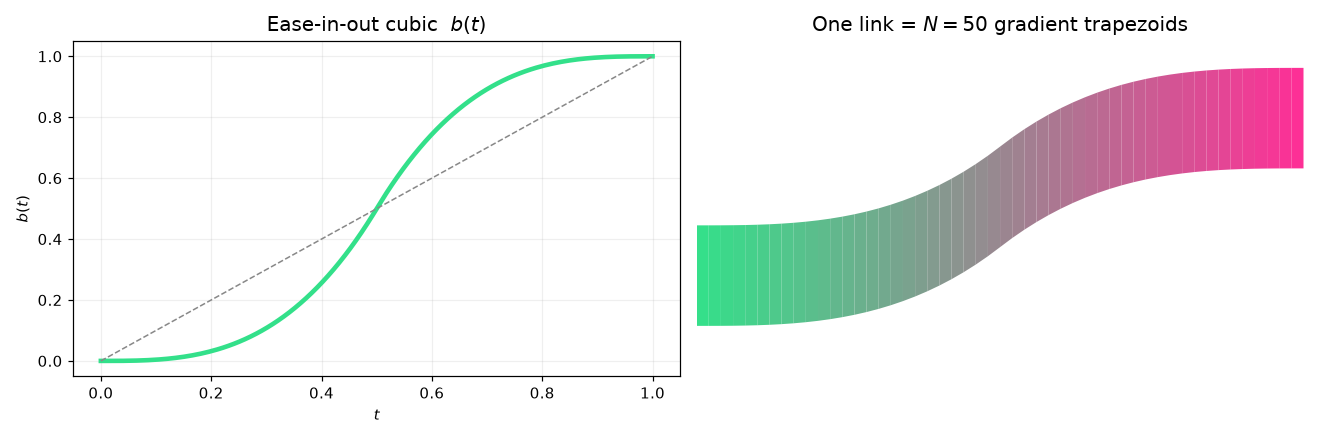

In [2]:
# Visualize the easing function b(t) and the per-segment color interpolation
def ease(t):
    return np.where(t < 0.5, 4*t**3, 1 - (-2*t + 2)**3 / 2)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4))
t = np.linspace(0, 1, 200)
axL.plot(t, ease(t), color="#33E08A", lw=3)
axL.plot([0, 1], [0, 1], "--", color="#888", lw=1)
axL.set_title(r"Ease-in-out cubic  $b(t)$", fontsize=13)
axL.set_xlabel("$t$"); axL.set_ylabel("$b(t)$"); axL.grid(alpha=.2)

# discretized gradient ribbon: N trapezoids from green -> magenta
N = 50
c0, c1 = np.array([0.20, 0.88, 0.54]), np.array([1.0, 0.18, 0.59])
tt = np.linspace(0, 1, N + 1); tm = (tt[:-1] + tt[1:]) / 2
ya0, yb0, h = 0.15, 0.62, 0.30
for i in range(N):
    x0, x1 = tt[i], tt[i+1]
    yb_lo = ya0 + (yb0 - ya0) * ease(np.array([x0, x1]))
    col = (1 - tm[i]) * c0 + tm[i] * c1
    axR.fill_between([x0, x1], [yb_lo[0], yb_lo[1]], [yb_lo[0]+h, yb_lo[1]+h],
                     color=col, edgecolor="none")
axR.set_title(r"One link = $N{=}50$ gradient trapezoids", fontsize=13)
axR.set_xlim(0, 1); axR.set_ylim(0, 1); axR.axis("off")
p = os.path.join(ASSETS, "01_atom.png"); fig.tight_layout(); fig.savefig(p, dpi=110); plt.close(fig)
show(p)


## 4. Nodes and the layered layout

Nodes live in ordered **layers** (left → right); each layer is a column of rounded rectangles. The library's first job is geometry: how tall is each node, and where does it sit?

In **stacked** mode the height of node $i$ is proportional to its value $v_i$, with a single global scale $s$ chosen so the *tallest* layer fills a target fraction of the canvas:

$$
s \;=\; \frac{H_{\text{stack}}}{\displaystyle\max_{\ell}\ \sum_{i\in\ell} v_i},
\qquad
h_i \;=\; \max(v_i\, s,\; h_{\min}).
$$

Using the **same** $s$ across all layers is what makes a waterfall legible: because $\sum K = P$ at every split, a node's incoming ribbon and its outgoing ribbons line up to the same height. The $h_{\min}$ floor keeps tiny nodes visible.

**Crossing reduction.** Within a node, the order in which flows stack determines whether ribbons tangle. The library stacks each node's **outgoing** flows by the *target's* vertical position and its **incoming** flows by the *source's* — a cheap heuristic that keeps the profit spine straight and pushes leaks to one side:

$$
\text{order}_{\text{out}}(e) \;=\; y_{\text{center}}\big(\text{target}(e)\big),
\qquad
\text{order}_{\text{in}}(e) \;=\; y_{\text{center}}\big(\text{source}(e)\big).
$$

The input contract is deliberately tiny: a **tidy DataFrame** (one row per flow: time, source, target, value) plus `layers` (a list of lists). Node names must be unique across layers.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\02_energy.png


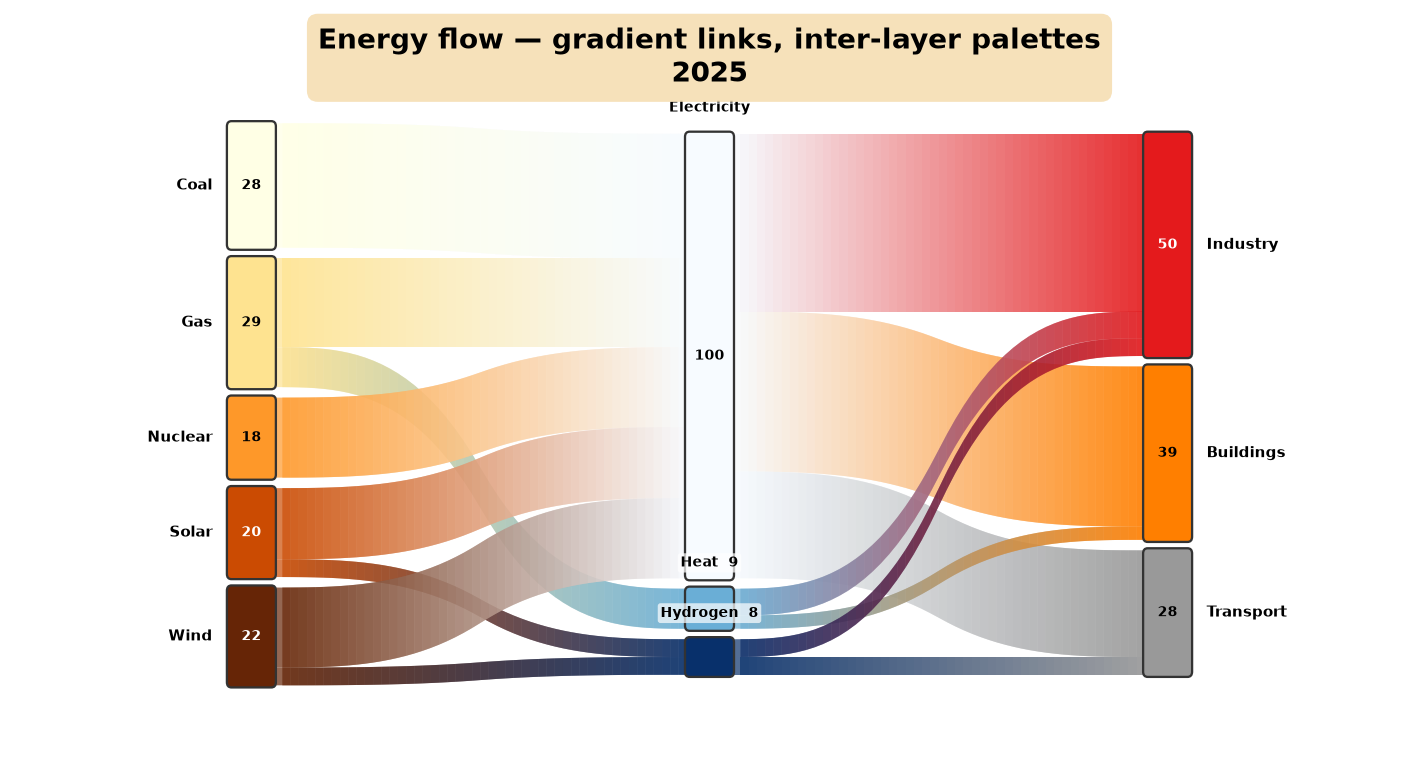

In [3]:
# A small synthetic 3-layer "energy transition" Sankey to show layout + inter-layer palettes
LAYERS = [["Coal", "Gas", "Nuclear", "Solar", "Wind"],   # sources
          ["Electricity", "Heat", "Hydrogen"],            # carriers
          ["Industry", "Buildings", "Transport"]]         # sectors
flows = {  # sources -> carriers (balanced so each carrier's inflow == outflow)
    ("Coal","Electricity"):28, ("Gas","Electricity"):20, ("Gas","Heat"):9,
    ("Nuclear","Electricity"):18, ("Solar","Electricity"):16, ("Solar","Hydrogen"):4,
    ("Wind","Electricity"):18, ("Wind","Hydrogen"):4,
    # carriers -> sectors  (Electricity in=100, Heat in=9, Hydrogen in=8)
    ("Electricity","Industry"):40, ("Electricity","Buildings"):36, ("Electricity","Transport"):24,
    ("Heat","Industry"):6, ("Heat","Buildings"):3,
    ("Hydrogen","Industry"):4, ("Hydrogen","Transport"):4}
df_energy = pd.DataFrame([{"year":2025,"source":s,"target":t,"value":v} for (s,t),v in flows.items()])

# inter-layer palettes: a distinct ColorPalette per layer, spread across that layer's nodes
layer_palettes = [ColorPalette.EARTH, ColorPalette.OCEAN, ColorPalette.NEON]
node_colors = {}
for nodes, pal in zip(LAYERS, layer_palettes):
    for n, c in zip(nodes, get_palette_colors(pal, len(nodes))):
        node_colors[n] = c

sk = Sankey.from_dataframe(df_energy, LAYERS, time_col="year", source_col="source",
                           target_col="target", value_col="value", node_colors=node_colors)
p = os.path.join(ASSETS, "02_energy.png")
sk.save_frame(p, frame_index=0, title="Energy flow — gradient links, inter-layer palettes",
              figsize=(13, 7), dpi=110, ranking_mode=False, stacked_mode=True)
show(p)


## 5. Four ways to position nodes

Two booleans give four behaviors, each answering a different analytical question:

| `ranking_mode` | `stacked_mode` | Behavior | Reads as |
|:---:|:---:|---|---|
| ✅ | ✅ | reorder by value **and** resize | "who is biggest, and by how much" |
| ✅ | ❌ | reorder by value, uniform heights | a pure **ranking race** |
| ❌ | ✅ | fixed order, heights vary by value | a **waterfall** (our P&L) |
| ❌ | ❌ | fixed order, uniform heights | stable comparison, only links move |

In **ranking** modes a layer is sorted by value before placement,

$$ \pi = \operatorname{argsort}_{\downarrow}\big(v_i\big),\qquad y_{\text{center}}(\pi_k)\ \text{decreasing in}\ k, $$

so the largest node rises to the top each frame. The income‑statement reel uses **fixed‑order stacked** (`ranking_mode=False, stacked_mode=True`) — the waterfall structure must stay put while magnitudes grow.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\03_mode_True_True.png
Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\03_mode_True_False.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\03_mode_False_True.png
Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\03_mode_False_False.png


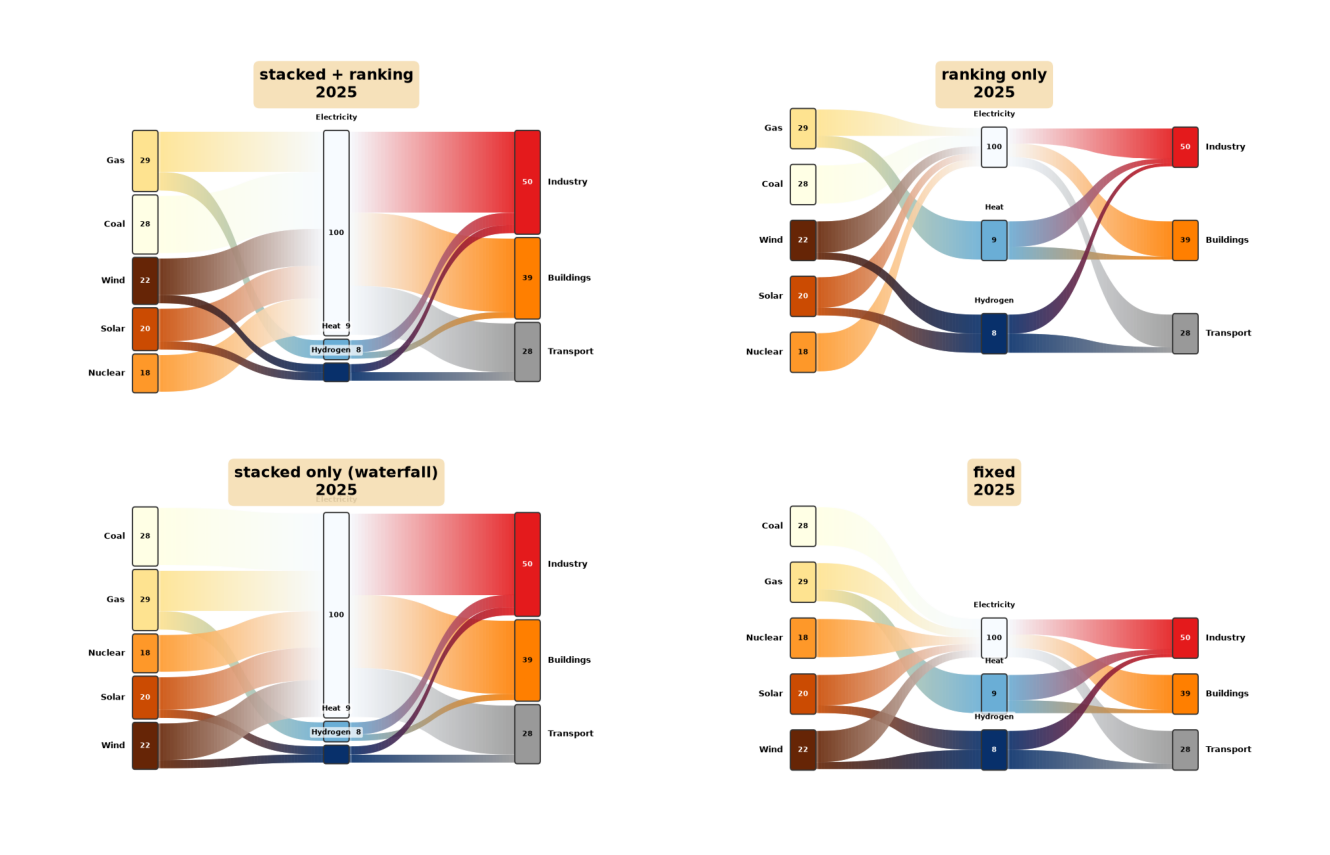

In [4]:
# Render the four positioning modes for the same data
modes = [("stacked + ranking", True, True), ("ranking only", True, False),
         ("stacked only (waterfall)", False, True), ("fixed", False, False)]
paths = []
for name, rm, sm in modes:
    p = os.path.join(ASSETS, f"03_mode_{rm}_{sm}.png")
    sk.save_frame(p, frame_index=0, title=name, figsize=(11, 6), dpi=90,
                  ranking_mode=rm, stacked_mode=sm)
    paths.append(p)
# stitch the four PNGs into a 2x2 grid for display
imgs = [plt.imread(p) for p in paths]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, im, (name, *_ ) in zip(axes.ravel(), imgs, modes):
    ax.imshow(im); ax.axis("off")
grid = os.path.join(ASSETS, "03_modes_grid.png"); fig.tight_layout(); fig.savefig(grid, dpi=95); plt.close(fig)
show(grid, w=1000)


## 6. Dynamic node colors

Beyond fixed brand colors, nodes can be **recolored every frame** from their value — turning the diagram into a heatmap that breathes. The library implements several schemes; the important ones, given a colormap $\Phi:[0,1]\to\text{RGB}$:

- **Ranking** (rank $r$ of $n$ in its layer): $\ \mathbf{c} = \Phi\!\left(1 - \dfrac{r-1}{n-1}\right)$ — 1st place green, last red.
- **Value** (normalized within a layer): $\ \mathbf{c} = \Phi\!\left(\dfrac{v - v_{\min}}{v_{\max} - v_{\min}}\right).$
- **Intensity** — keep each node's *hue* but scale its brightness/saturation by value, normalized **globally** and $\sqrt{\cdot}$‑compressed so early small values stay visible. In HSV, with $x = v/v_{\max}^{\text{global}}$,

$$ V' = V\cdot\Big(f_0 + (1-f_0)\sqrt{x}\Big),\qquad S' = S\cdot(0.45 + 0.55\,x), $$

with a floor $f_0=0.30$. This makes a chart literally **light up** as a company grows, without changing any bar size.


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\04_dyncolor.png


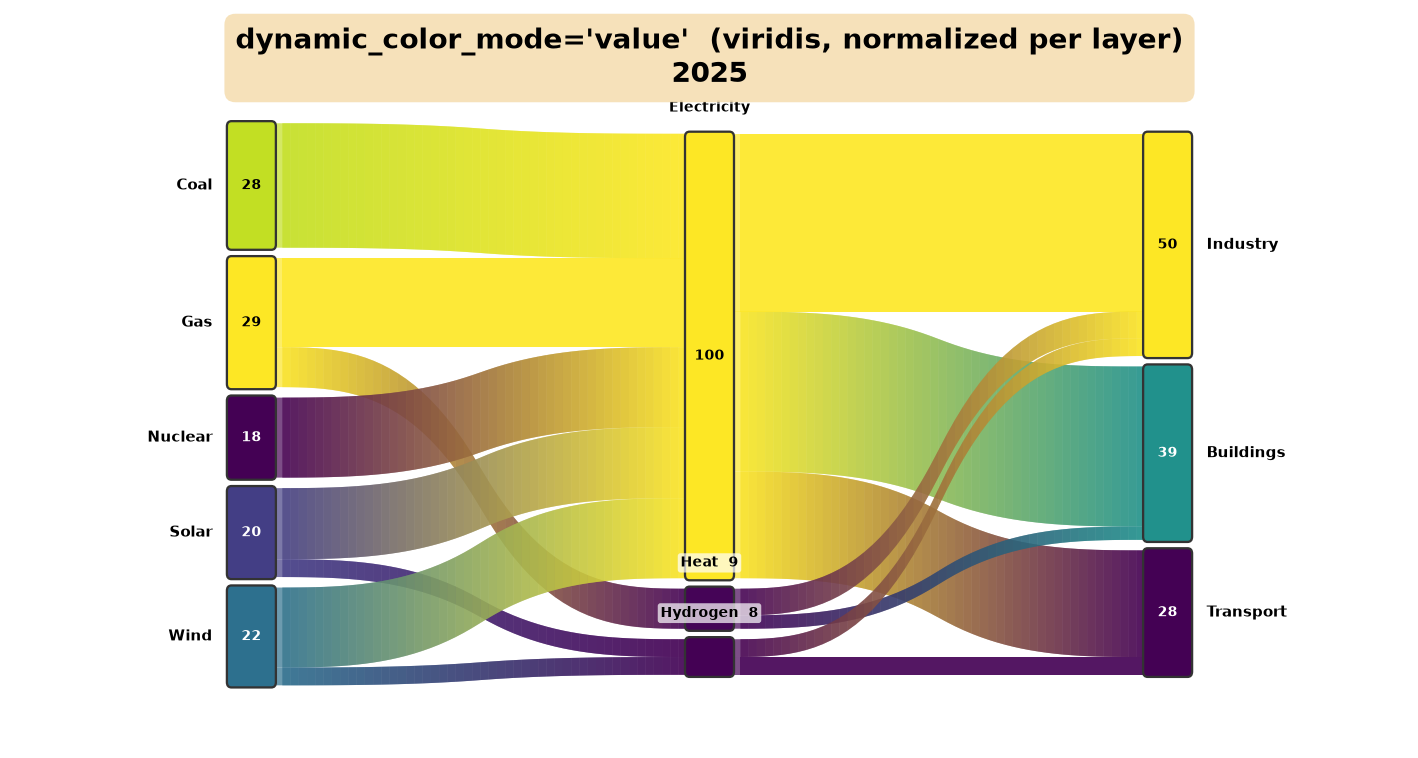

In [5]:
# Show value-based dynamic colors on the energy data (static snapshot of the per-frame logic)
vals = sk._compute_node_values(sk.frames[0]["links"])
dyn = sk._compute_dynamic_colors(vals, mode="value", colormap="viridis")
sk_dyn = Sankey.from_dataframe(df_energy, LAYERS, time_col="year", source_col="source",
                               target_col="target", value_col="value", node_colors=dyn)
p = os.path.join(ASSETS, "04_dyncolor.png")
sk_dyn.save_frame(p, frame_index=0, title="dynamic_color_mode='value'  (viridis, normalized per layer)",
                  figsize=(13, 7), dpi=110, ranking_mode=False, stacked_mode=True)
show(p)


## 7. From a still to a story: animation

A dataset has a handful of **key frames** (one per quarter). To animate, the library interpolates between consecutive keys $a \to b$. For a fraction $t\in[0,1]$, every flow value, node position and (optionally) color is linearly blended:

$$
v(t) = v_a + (v_b - v_a)\,t,\qquad
y(t) = y_a + (y_b - y_a)\,t,\qquad
\mathbf{c}(t) = (1-t)\,\mathbf{c}_a + t\,\mathbf{c}_b .
$$

With `fps` and `duration` the total frame count is $F = \lfloor \text{fps}\cdot T\rfloor$, split into $\lfloor F/(n_{\text{keys}}{-}1)\rfloor$ interpolated frames per gap plus a hold at the end.

> **A bug worth telling.** The interpolator originally dropped any link with $v \le 0.1$ to avoid flicker. That constant is fine for large numbers but catastrophic for an income statement measured in **billions** — a real \$0.085 B flow silently vanished, leaving nodes with missing arrows in NVIDIA's early years. The fix is to keep every real link and let a vanishing one shrink smoothly:
> $$ \text{render link} \iff v > \varepsilon,\qquad \varepsilon = 10^{-9}. $$
> A magnitude‑independent threshold. *Lesson: never hard‑code an absolute cutoff on user data whose units you don't control.*



## 8. Rendering at scale (and making it fast)

A 90‑second reel at 30 fps is **2,700 frames**. Each frame draws hundreds of gradient trapezoids. Two engineering decisions keep this tractable.

**Parallelism + a raw video pipe.** Frames are split into $W$ chunks; each worker process renders its chunk and streams raw RGB straight into an FFmpeg `libx264` encoder via stdin; the chunk MP4s are concatenated at the end. Speedup is roughly linear in worker count.

**Vectorizing the hot path.** The inner loop assembled each segment's quad as Python tuples — $2700 \times 6 \times 50 \approx 8\times10^{5}$ allocations per reel. Replacing it with a single NumPy build per link,

$$
\underbrace{V}_{(N,\,4,\,2)} = \texttt{stack}\big[(x_0,y_0^{\text{bot}}),\,(x_0,y_0^{\text{top}}),\,(x_1,y_1^{\text{top}}),\,(x_1,y_1^{\text{bot}})\big],
$$

then `concatenate`‑ing all links into one `PolyCollection`, collapses that loop. Measured per‑frame *build* time:

| $N$ (segments) | before | after |
|:---:|:---:|:---:|
| 50  | 42 ms | **34 ms** |
| 100 | 60 ms | **33 ms** |

The build cost goes from *linear* in $N$ to roughly *flat*. I verified the rewrite is **pixel‑identical** to the original across 39 feature combinations (max difference $= 0/255$) before shipping it — an optimization that changes a single pixel isn't an optimization, it's a regression.


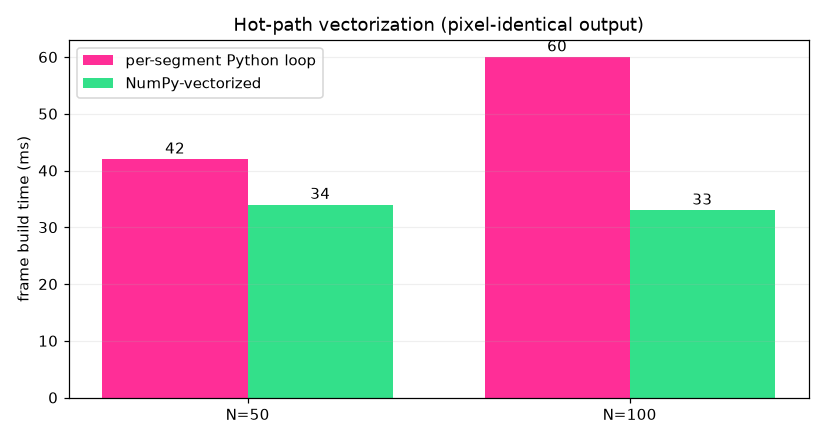

In [6]:
# The measured optimization, as a chart
N = [50, 100]; before = [42, 60]; after = [34, 33]
fig, ax = plt.subplots(figsize=(7.5, 4))
x = np.arange(len(N)); w = 0.38
ax.bar(x - w/2, before, w, label="per-segment Python loop", color="#FF2E97")
ax.bar(x + w/2, after,  w, label="NumPy-vectorized",        color="#33E08A")
for xi, b, a in zip(x, before, after):
    ax.text(xi - w/2, b + 1, f"{b}", ha="center"); ax.text(xi + w/2, a + 1, f"{a}", ha="center")
ax.set_xticks(x); ax.set_xticklabels([f"N={n}" for n in N])
ax.set_ylabel("frame build time (ms)"); ax.set_title("Hot-path vectorization (pixel-identical output)")
ax.legend(); ax.grid(axis="y", alpha=.2)
p = os.path.join(ASSETS, "05_speedup.png"); fig.tight_layout(); fig.savefig(p, dpi=110); plt.close(fig)
show(p, w=650)


## 9. Case study — NVIDIA's income statement, FY2009 → FY2027

This is where the library earns its keep: a real company, real filings, real history.

### 9.1 Pulling the data from SEC EDGAR

The SEC exposes every filer's XBRL facts through a free JSON API. For NVIDIA (CIK `0001045810`) we query the **company‑concept** endpoint per US‑GAAP tag:

```
https://data.sec.gov/api/xbrl/companyconcept/CIK0001045810/us-gaap/{Tag}.json
```

We pull only four robust series that reach back to 2008 — **Revenues, GrossProfit, OperatingIncomeLoss, NetIncomeLoss** — and **derive** the cost "leaks" as residuals, so the waterfall balances by construction:

$$
\text{COGS} = \text{Rev} - \text{GP},\quad
\text{OpEx} = \text{GP} - \text{OpInc},\quad
\text{Tax\&Other} = \text{OpInc} - \text{NI}.
$$

Three data‑engineering subtleties had to be handled:

1. **The missing fiscal Q4.** XBRL never reports Q4 as a standalone $\sim$91‑day fact — only the full year ($\sim$365 d) and the nine‑month YTD ($\sim$273 d). So each Q4 is *derived*:
$$ Q4 = \text{FullYear} - \text{NineMonthYTD}. $$
Without this the time series has a hole every single year.

2. **NVIDIA's fiscal calendar runs $\sim$11 months ahead.** FY2027 began in Feb 2026, so "FY2027 Q1" is the quarter that **ended Apr 2026** — a *closed, reported* quarter, not a projection. Labels carry the calendar period‑end to avoid that confusion.

3. **Network hygiene.** SEC requires a descriptive `User-Agent`; requests retry with backoff, and results are cached to CSV so a render is reproducible and offline.


In [7]:
# The NVIDIA P&L ships with the repo as a cached CSV (examples/data/), so this
# notebook is fully self-contained -- no SEC calls, offline & reproducible. (The
# 01_tutorial_nvidia_income notebook shows how that CSV is scraped from SEC EDGAR;
# here we just load it and rebuild the balanced waterfall.)
NV_CSV = os.path.join(os.path.abspath(".."), "examples", "data", "nvidia_dre_wide.csv")

def build():
    # Load the cached NVIDIA quarterly P&L (one row per fiscal quarter), deriving
    # the residual 'leak' columns if the CSV doesn't already carry them.
    w = pd.read_csv(NV_CSV)
    if "cogs" not in w:      w["cogs"]      = w["revenue"]      - w["gross_profit"]
    if "opex" not in w:      w["opex"]      = w["gross_profit"] - w["op_income"]
    if "tax_other" not in w: w["tax_other"] = w["op_income"]    - w["net_income"]
    return w

# Income-statement layers, left -> right (full node names).
NV_LAYERS = [["Revenue"], ["Gross Profit", "Cost of Revenue"],
             ["Operating Income", "Operating Expenses"], ["Net Income", "Tax & Other"]]

def to_flows(w):
    # Tidy [quarter, source, target, value] flows with the BALANCED waterfall: each
    # kept spine is clamped to [0, parent] so loss quarters never 'emit more than
    # they receive'. Values stay in raw US$ (the caller scales to $B).
    def clamp(x, lo, hi): return max(lo, min(x, hi))
    rows = []
    for _, r in w.iterrows():
        rev, gp, op, ni = r["revenue"], r["gross_profit"], r["op_income"], r["net_income"]
        gross_kept = clamp(gp, 0.0, rev)
        op_kept    = clamp(op, 0.0, gross_kept)
        net_kept   = clamp(ni, 0.0, op_kept)
        for src, tgt, val in [
            ("Revenue",          "Gross Profit",       gross_kept),
            ("Revenue",          "Cost of Revenue",    rev - gross_kept),
            ("Gross Profit",     "Operating Income",   op_kept),
            ("Gross Profit",     "Operating Expenses", gross_kept - op_kept),
            ("Operating Income", "Net Income",         net_kept),
            ("Operating Income", "Tax & Other",        op_kept - net_kept),
        ]:
            rows.append({"quarter": r["quarter"], "source": src,
                         "target": tgt, "value": max(val, 0.0)})
    return pd.DataFrame(rows)

wide = build()  # reads examples/data/nvidia_dre_wide.csv
b = wide[["quarter","revenue","gross_profit","op_income","net_income","cogs","opex","tax_other"]].copy()
for c in b.columns[1:]:
    b[c] = (b[c] / 1e9).round(2)   # -> $B
print(f"{len(wide)} quarters: {wide['quarter'].iloc[0]}  ->  {wide['quarter'].iloc[-1]}\n")
print("First & last quarters ($B):")
display(pd.concat([b.head(3), b.tail(3)]))

# verify the waterfall identities hold (residual leaks)
ok = (np.allclose(wide.cogs, wide.revenue - wide.gross_profit) and
      np.allclose(wide.opex, wide.gross_profit - wide.op_income) and
      np.allclose(wide.tax_other, wide.op_income - wide.net_income))
print("\nWaterfall identities (COGS, OpEx, Tax&Other) hold:", ok)

72 quarters: FY2009 Q2 (Jul 2008)  ->  FY2027 Q1 (Apr 2026)

First & last quarters ($B):


,quarter,revenue,gross_profit,op_income,net_income,cogs,opex,tax_other
0,FY2009 Q2 (Jul 2008),0.89,0.15,-0.16,-0.12,0.74,0.31,-0.03
1,FY2009 Q3 (Oct 2008),0.90,0.37,0.06,0.06,0.53,0.31,-0.00
2,FY2009 Q4 (Jan 2009),0.48,0.14,-0.18,-0.15,0.34,0.32,-0.03
69,FY2026 Q3 (Oct 2025),57.01,41.85,36.01,31.91,15.16,5.84,4.10
70,FY2026 Q4 (Jan 2026),68.13,51.09,44.30,42.96,17.03,6.79,1.34
71,FY2027 Q1 (Apr 2026),81.61,61.16,53.54,58.32,20.46,7.62,-4.78



Waterfall identities (COGS, OpEx, Tax&Other) hold: True



### 9.2 The loss‑quarter problem

A Sankey flows downward, so a child flow can never exceed its parent. But in a **loss** quarter (2009–2010, several quarters) operating income is negative, which makes the derived leak *larger than the parent*:

$$ \text{OpInc} < 0 \;\Rightarrow\; \text{OpEx} = \text{GP} - \text{OpInc} > \text{GP}. $$

Naively sizing bars by $|\,\cdot\,|$ then makes a node "emit more than it receives" — a broken diagram. The fix builds the waterfall **top‑down with clamping**, so every node's outflow equals its inflow exactly:

$$
\text{kept} = \operatorname{clamp}\!\big(\text{signed},\,0,\,\text{parent}\big),\qquad
\text{leak} = \text{parent} - \text{kept}.
$$

For profitable quarters this is identical to the raw residuals; for loss quarters the green **profit spine simply pinches to zero** — an honest, legible picture — while the label still shows the true signed figure in parentheses. (The same limitation explains why *Tax & Other* goes negative in recent quarters: NVIDIA's net income now **exceeds** operating income thanks to billions in interest and investment income that *add* below the operating line.)


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\06_nv_0.png


Frame saved to: C:\Users\Felipe\Downloads\python_projects\math_projects\animated_sankey_plot\notebooks\_nb_assets\06_nv_71.png


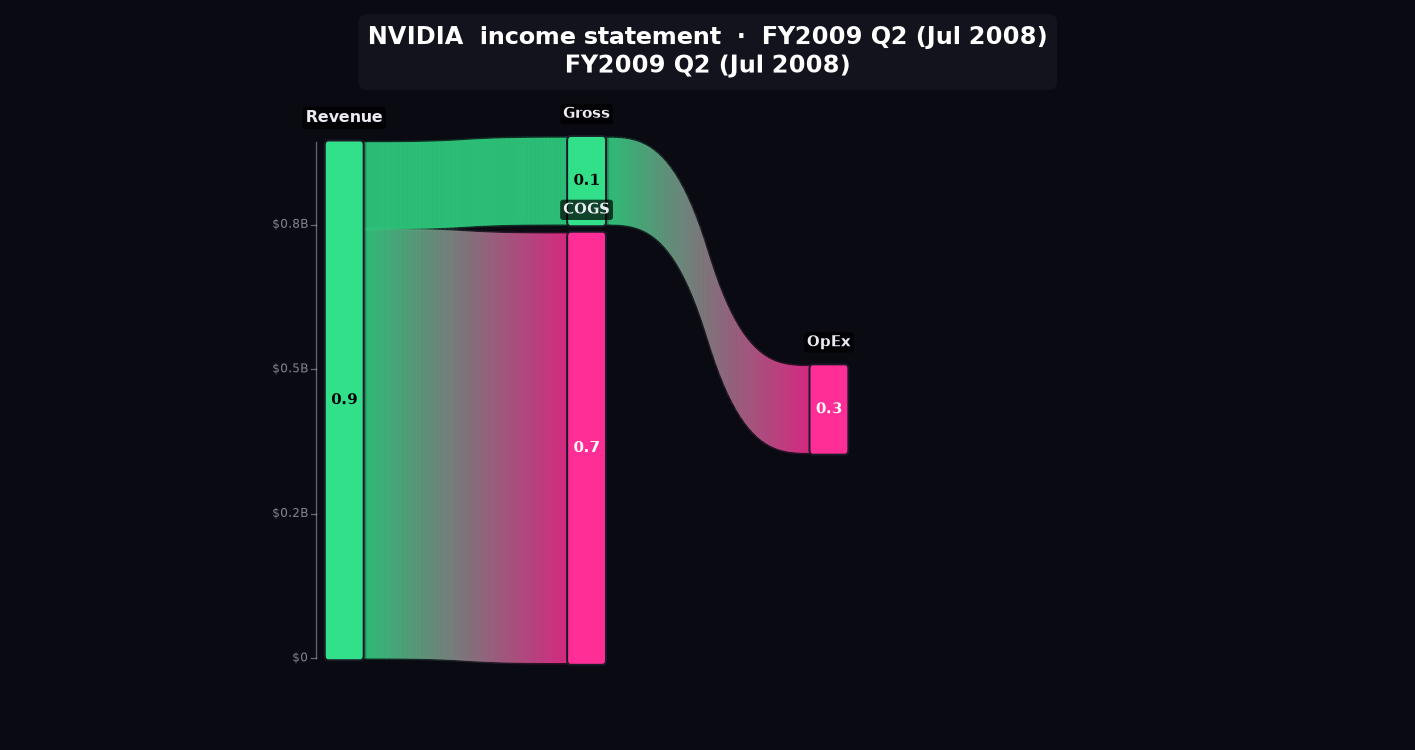

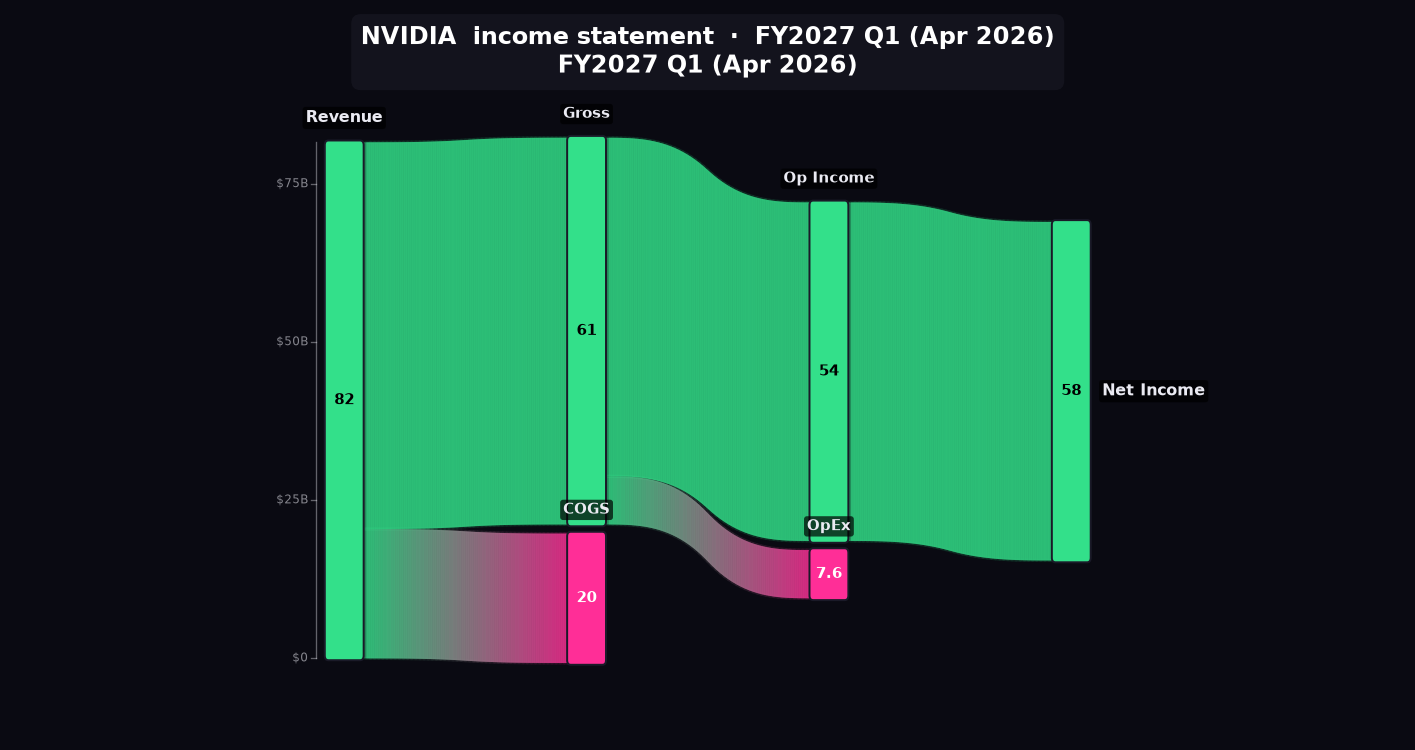

In [8]:
# Render two NVIDIA quarters side-by-side: an early loss-ish quarter vs the 2026 explosion.
SHORT = {"Revenue":"Revenue","Gross Profit":"Gross","Cost of Revenue":"COGS",
         "Operating Income":"Op Income","Operating Expenses":"OpEx",
         "Net Income":"Net Income","Tax & Other":"Tax+Other"}
POS = ["#33E08A", "#FF2E97"]
LCOL = {"Revenue":"revenue","Gross":"gross_profit","COGS":"cogs","Op Income":"op_income",
        "OpEx":"opex","Net Income":"net_income","Tax+Other":"tax_other"}
def fmt(v):
    a = abs(v); s = f"{a:.1f}" if a < 10 else f"{a:.0f}"
    return f"({s})" if v < 0 else s

flows = to_flows(wide); flows["value"] = flows["value"]/1e9
flows["source"] = flows["source"].map(lambda s: SHORT.get(s, s))
flows["target"] = flows["target"].map(lambda s: SHORT.get(s, s))
layers = [["Revenue"],["Gross","COGS"],["Op Income","OpEx"],["Net Income","Tax+Other"]]
nc = {n: POS[i] for L in layers for i, n in enumerate(L)}
order = sorted(flows["quarter"].unique())
by_q = {r["quarter"]: r for _, r in wide.iterrows()}
sk_nv = Sankey.from_dataframe(flows, layers, time_col="quarter", source_col="source",
                              target_col="target", value_col="value", node_colors=nc)

paths = []
# an early LOSS quarter (profit spine pinches to zero) and the 2026 explosion
loss_idx = next((i for i, q in enumerate(order) if by_q[q]["op_income"] < 0), 6)
for q in [order[loss_idx], order[-1]]:
    idx = order.index(q)
    labels = {n: fmt(by_q[q][c]/1e9) for n, c in LCOL.items()}
    p = os.path.join(ASSETS, f"06_nv_{idx}.png")
    sk_nv.save_frame(p, frame_index=idx, title=f"NVIDIA  income statement  ·  {q}",
                     figsize=(15, 8), dpi=95, font_size=12, title_fontsize=18, padding=2.2,
                     theme="dark", link_glow=1, link_alpha=0.55, ranking_mode=False, stacked_mode=True,
                     node_value_labels=labels, yaxis_node="Revenue", yaxis_suffix="B")
    paths.append(p)
for p in paths:
    display(show(p, w=1000))


### 9.3 The stock‑price overlay

To connect fundamentals to the market, the reel overlays NVIDIA's **split‑adjusted closing price**, sampled at each quarter‑end, as a *bar‑chart‑race* style footer: the time axis advances while the curve always fills the width and the $y$‑axis tracks the running maximum. The price is pulled via `yfinance` with `auto_adjust=True`, so the 10:1 (2024) and 4:1 (2021) splits are handled. The story it tells is stark: **\$0.27 → \$208** while quarterly revenue went from **\$0.9 B → \$82 B**.


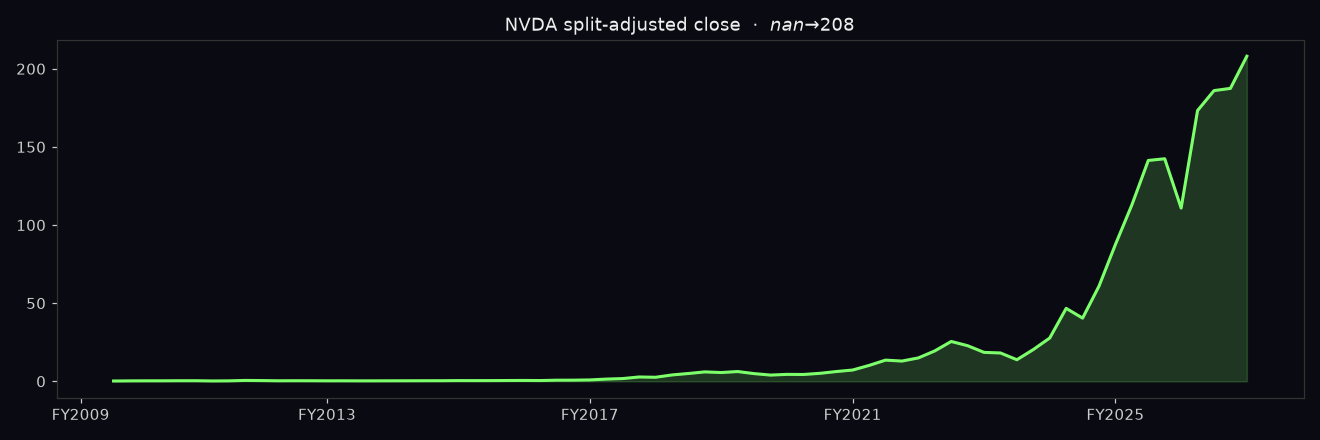

In [9]:
# Pull NVDA split-adjusted close and align to quarter-ends (gracefully skips if offline)
try:
    import yfinance as yf
    px = yf.Ticker("NVDA").history(start="2009-01-01", auto_adjust=True)["Close"]
    px.index = px.index.tz_localize(None)
    qdates = pd.to_datetime([by_q[q]["period"] for q in order])
    series = [float(px.asof(d)) for d in qdates]
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(range(len(series)), series, color="#7CFF6B", alpha=.18)
    ax.plot(series, color="#7CFF6B", lw=2)
    yrs = [q.split()[0] for q in order]
    ticks = [i for i in range(len(yrs)) if i == 0 or yrs[i] != yrs[i-1]][::4]
    ax.set_xticks(ticks); ax.set_xticklabels([yrs[i] for i in ticks], rotation=0)
    ax.set_title(f"NVDA split-adjusted close  ·  ${series[0]:.2f}  →  ${series[-1]:.0f}")
    ax.set_facecolor("#0a0a12"); fig.patch.set_facecolor("#0a0a12")
    ax.tick_params(colors="#ccc"); ax.title.set_color("#eee")
    for s in ax.spines.values(): s.set_color("#333")
    p = os.path.join(ASSETS, "07_stock.png"); fig.tight_layout(); fig.savefig(p, dpi=110, facecolor="#0a0a12"); plt.close(fig)
    display(show(p, w=900))
except Exception as e:
    print("yfinance unavailable offline — overlay is optional:", e)


## 10. Results & validation

The final deliverable is a **90‑second reel of NVIDIA's income statement, FY2009 → FY2027**, dark‑themed with neon‑glow gradient links, accounting‑style labels (negatives in parentheses), an evolving \$ value axis on Revenue, the stock‑price footer, and a synchronized music track — rendered in parallel and muxed with FFmpeg.

Because correctness mattered more than cleverness, every change was regression‑tested:

| Suite | Coverage | Result |
|---|---|:---:|
| Unit + smoke (`pytest`) | palettes, geometry, validation, render | **34 / 34** |
| Static feature diff (old vs new, pixel‑exact) | 39 combos: modes, themes, glow, dynamic colors, $N$, overlay, layouts, 2–5 layers | **39 / 39 identical** |
| Animation pipeline | 4 modes × dynamic colors × overlay × audio × worker‑clamp | **16 / 16** |
| Edge cases | empty / NaN / duplicate / single‑node / huge inputs | **25 / 25** |

The optimization, the small‑link fix, the loss‑quarter balancing and the resilient parallel renderer all landed **without breaking a single feature**.



## 11. Try it — the open‑source library

The whole thing is MIT‑licensed and on GitHub. The public API is small:

```bash
pip install gradient-sankey            # core
pip install "gradient-sankey[finance,audio]"   # + SEC/yfinance + YouTube audio
```

```python
import pandas as pd
from gradient_sankey import SankeyRaceMultiLayerParallel as Sankey

df = pd.DataFrame([...])   # tidy: time, source, target, value
layers = [["Revenue"], ["Gross", "COGS"], ["Op Income", "OpEx"], ["Net Income", "Tax+Other"]]

sk = Sankey.from_dataframe(df, layers, time_col="quarter",
                           source_col="source", target_col="target", value_col="value")

sk.save_frame("frame.png", theme="dark", link_glow=1)          # a still
sk.animate("reel.mp4", fps=30, duration_seconds=90,            # the movie
           ranking_mode=False, stacked_mode=True,
           yaxis_node="Revenue", overlay_series=stock_prices,
           audio_url="https://youtu.be/...", audio_start=269)
```

**Repo:** https://github.com/FG-SC/gradient-sankey



## 12. What the journey taught me

- **Visualization is a communication problem first.** The gradient isn't decoration — it's the cheapest way to make overlapping flows legible to a non‑technical audience.
- **The hard part of a "data viz" project is the data.** Deriving Q4 from YTD, balancing loss quarters, and getting the fiscal calendar right was more work than the rendering math.
- **Optimize only what you can prove is identical.** A pixel‑diff harness turned "I think it's faster" into "it's 2× faster and byte‑for‑byte the same."
- **Hard‑coded constants are bugs waiting for the wrong units.** A `0.1` cutoff meant for unit‑scale data quietly deleted billion‑dollar flows.

From a slide I wished existed in a client deck to an MIT‑licensed library and a NVIDIA reel — that's the arc. The math is simple; the discipline is in the details.

---
*Built with Python, NumPy, Matplotlib and FFmpeg. Data: SEC EDGAR (XBRL) and Yahoo Finance.*
